In [55]:
# 1. Cloner le repository

!git clone https://github.com/fatimazahramassane/projet_ai.git
!cd projet_ai


fatal: destination path 'projet_ai' already exists and is not an empty directory.


In [56]:
# Configuration environnement Colab/Local
import sys, os, pathlib
import warnings
warnings.filterwarnings('ignore')

# Détection automatique
if 'google.colab' in str(get_ipython()):
    PROJECT_ROOT = pathlib.Path("/content/projet_ai")
    %cd /content/projet_ai
else:
    PROJECT_ROOT = pathlib.Path.cwd().parent if 'notebooks' in str(pathlib.Path.cwd()) else pathlib.Path.cwd()

# Ajouter src/ au path
src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Créer dossiers de sortie
for folder in ["reports/figures", "reports/tables", "models"]:
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)

# Fixer seeds
import numpy as np
np.random.seed(42)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"Dossiers de sortie créés")

/content/projet_ai
PROJECT_ROOT = /content/projet_ai
Dossiers de sortie créés


In [59]:
# =============================================================================
# 🔍 VÉRIFICATION COMPLÈTE DU PROJET — APS Failure Scania
# =============================================================================
import os, sys, subprocess, json, time
from pathlib import Path
from google.colab import files

print("🔍 VÉRIFICATION DU PROJET — Google Colab")
print("="*70)

# 1. Cloner le repo (si pas déjà fait)
PROJECT = "/content/projet_ai"
if not os.path.exists(PROJECT):
    print("📥 Clonage du repository GitHub...")
    !git clone https://github.com/fatimazahramassane/projet_ai.git {PROJECT}
%cd {PROJECT}
print(f"✅ Dossier actif : {os.getcwd()}\n")

# 2. Vérification de la structure des dossiers
print("📁 STRUCTURE DES DOSSIERS")
print("-"*70)
required_dirs = [
    "notebooks", "src/data", "src/evaluation", "src/preprocessing",
    "src/utils", "scripts", "reports/figures", "reports/tables", "models"
]
for d in required_dirs:
    exists = os.path.exists(d)
    status = "✅" if exists else "❌"
    print(f"{status} {d}")
print()

# 3. Vérification des fichiers critiques
print("📄 FICHIERS CRITIQUES")
print("-"*70)
required_files = {
    "requirements.txt": "Dépendances Python",
    "README.md": "Documentation projet",
    ".gitignore": "Exclusions Git",
    "notebooks/01_eda_preprocessing.ipynb": "Notebook EDA",
    "notebooks/02_model_training.ipynb": "Notebook Modèles",
    "notebooks/03_evaluation_calibration.ipynb": "Notebook Calibration",
    "notebooks/04_shap_analysis.ipynb": "Notebook SHAP",
    "src/data/loader.py": "Chargement données",
    "src/evaluation/metrics.py": "Métriques F1/AUPRC/MCC",
    "src/evaluation/calibration.py": "Calibration ECE",
    "src/evaluation/plots.py": "Visualisations",
    "src/preprocessing/pipeline.py": "Pipelines anti-leakage",
    "src/utils/reproducibility.py": "Seeds & logging",
    "scripts/generate_all_figures.py": "Génération figures",
    "scripts/fill_report.py": "Remplissage rapport",
}
for path, desc in required_files.items():
    exists = os.path.exists(path)
    status = "✅" if exists else "❌"
    print(f"{status} {path:45s} — {desc}")
print()

# 4. Vérification du dataset
print("📊 DATASET APS SCANIA")
print("-"*70)
data_dir = "data/raw/aps_scania"
os.makedirs(data_dir, exist_ok=True)

# Télécharger si absent
train_csv = f"{data_dir}/aps_failure_training_set.csv"
if not os.path.exists(train_csv):
    print("📥 Téléchargement du dataset...")
    !wget -q "https://archive.ics.uci.edu/ml/machine-learning-databases/00421/aps_failure_training_set.csv" -O {train_csv}
    !wget -q "https://archive.ics.uci.edu/ml/machine-learning-databases/00421/aps_failure_test_set.csv" -O {data_dir}/aps_failure_test_set.csv

# Vérifier
if os.path.exists(train_csv):
    import pandas as pd
    df = pd.read_csv(train_csv, skiprows=20, nrows=2)
    print(f"✅ Train : {train_csv}")
    print(f"   Shape : {df.shape} | Colonnes : {df.shape[1]}")
    print(f"   Target 'class' : {df['class'].unique() if 'class' in df.columns else '❌ NON TROUVÉE'}")
else:
    print(f"❌ Dataset non trouvé : {train_csv}")
print()

# 5. Test d'import des modules src/
print("🔧 TEST D'IMPORT DES MODULES src/")
print("-"*70)
sys.path.insert(0, PROJECT)
try:
    from src.data.loader import load_aps_data, get_X_y, compute_total_cost
    print("✅ src/data/loader.py")
except ImportError as e:
    print(f"❌ src/data/loader.py — {e}")

try:
    from src.evaluation.metrics import compute_all_metrics, find_optimal_threshold
    print("✅ src/evaluation/metrics.py")
except ImportError as e:
    print(f"❌ src/evaluation/metrics.py — {e}")

try:
    from src.evaluation.calibration import compute_ece, plot_reliability_diagram
    print("✅ src/evaluation/calibration.py")
except ImportError as e:
    print(f"❌ src/evaluation/calibration.py — {e}")

try:
    from src.preprocessing.pipeline import create_model_pipeline, verify_no_leakage
    print("✅ src/preprocessing/pipeline.py")
except ImportError as e:
    print(f"❌ src/preprocessing/pipeline.py — {e}")

try:
    from src.utils.reproducibility import set_all_seeds, log_environment_info
    print("✅ src/utils/reproducibility.py")
except ImportError as e:
    print(f"❌ src/utils/reproducibility.py — {e}")
print()

# 6. Vérification des dépendances
print("📦 VÉRIFICATION DES DÉPENDANCES")
print("-"*70)
required_packages = [
    "pandas", "numpy", "scikit-learn", "imbalanced-learn", "xgboost",
    "optuna", "shap", "umap-learn", "statsmodels", "seaborn", "matplotlib"
]
for pkg in required_packages:
    try:
        __import__(pkg)
        print(f"✅ {pkg}")
    except ImportError:
        print(f"❌ {pkg} — À installer : pip install {pkg}")
print()

# 7. Résumé final
print("\n" + "="*70)
print("📋 RÉSUMÉ DE LA VÉRIFICATION")
print("="*70)

# Compter les OK/❌
checks = [
    os.path.exists(d) for d in required_dirs
] + [
    os.path.exists(f) for f in required_files.keys()
] + [
    os.path.exists(train_csv)
]

ok_count = sum(checks)
total_count = len(checks)
success_rate = ok_count / total_count * 100

if success_rate >= 95:
    print(f"🎉 PROJET PRÊT ! ({ok_count}/{total_count} vérifications OK)")
    print("✅ Tu peux maintenant exécuter les notebooks dans l'ordre :")
    print("   1. notebooks/01_eda_preprocessing.ipynb")
    print("   2. notebooks/02_model_training.ipynb")
    print("   3. notebooks/03_evaluation_calibration.ipynb")
    print("   4. notebooks/04_shap_analysis.ipynb")
elif success_rate >= 80:
    print(f"⚠️ PRESQUE PRÊT ({ok_count}/{total_count} OK)")
    print("   Corrige les éléments ❌ ci-dessus avant d'exécuter.")
else:
    print(f"❌ PROJET INCOMPLET ({ok_count}/{total_count} OK)")
    print("   Vérifie le clonage GitHub et la structure des dossiers.")

print("\n💡 Astuce : Si un module manque, exécute :")
print("   !pip install -r requirements.txt")

🔍 VÉRIFICATION DU PROJET — Google Colab
/content/projet_ai
✅ Dossier actif : /content/projet_ai

📁 STRUCTURE DES DOSSIERS
----------------------------------------------------------------------
✅ notebooks
✅ src/data
✅ src/evaluation
✅ src/preprocessing
✅ src/utils
✅ scripts
✅ reports/figures
✅ reports/tables
✅ models

📄 FICHIERS CRITIQUES
----------------------------------------------------------------------
✅ requirements.txt                              — Dépendances Python
✅ README.md                                     — Documentation projet
✅ .gitignore                                    — Exclusions Git
✅ notebooks/01_eda_preprocessing.ipynb          — Notebook EDA
✅ notebooks/02_model_training.ipynb             — Notebook Modèles
✅ notebooks/03_evaluation_calibration.ipynb     — Notebook Calibration
✅ notebooks/04_shap_analysis.ipynb              — Notebook SHAP
✅ src/data/loader.py                            — Chargement données
✅ src/evaluation/metrics.py                     —

In [60]:
# ============================================================
# 🛠️ RÉPARATION FINALE & PRÉPARATION EXÉCUTION
# ============================================================
import os

# 1. Installer les librairies manquantes (scikit-learn, imblearn, umap)
print("📦 Installation des dépendances...")
!pip install -q -r requirements.txt
!pip install -q umap-learn  # Force install car parfois oublié par pip

# 2. Créer les scripts utilitaires manquants (pour la fin du projet)
print("📝 Création des scripts manquants...")
os.makedirs('scripts', exist_ok=True)

# Script 1: Génération de figures
with open('scripts/generate_all_figures.py', 'w') as f:
    f.write("""
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

PROJECT = "."
FIGURES = os.path.join(PROJECT, "reports/figures")
os.makedirs(FIGURES, exist_ok=True)

# Load data
data_path = os.path.join(PROJECT, "data/raw/aps_scania/aps_failure_training_set.csv")
df = pd.read_csv(data_path, skiprows=20)
df = df.replace('na', float('nan'))
y = (df['class'] == 'pos').astype(int)

# Fig 1: Target
plt.figure(figsize=(5,4))
plt.bar(['Neg', 'Pos'], [len(df)-y.sum(), y.sum()], color=['blue', 'red'])
plt.title("Target Distribution")
plt.savefig(os.path.join(FIGURES, "01_target_distribution.png"))
plt.close()
print("✅ Figure 01 créée")
""")

# Script 2: Remplissage rapport
with open('scripts/fill_report.py', 'w') as f:
    f.write("""
import pandas as pd
from pathlib import Path
import re

PROJECT = Path(".")
csv_path = PROJECT / "reports/tables/final_comparison.csv"
if csv_path.exists():
    df = pd.read_csv(csv_path)
    best = df.loc[df['MCC'].idxmax()]
    metrics = {'best_model': best['Model'], 'best_mcc': f"{best['MCC']:.4f}"}

    report = PROJECT / "rapport_aps_scania.md"
    if report.exists():
        text = report.read_text()
        for k, v in metrics.items():
            text = re.sub(rf"{{{{{k}}}}}", v, text)
        report.write_text(text)
        print(f"✅ Rapport mis à jour avec {metrics}")
""")

print("\n PRÊT ! Tout est installé.")

📦 Installation des dépendances...
📝 Création des scripts manquants...

 PRÊT ! Tout est installé.


In [61]:
import os, sys

# 1. Corriger le chemin vers le vrai repo
if os.path.exists("/content/projet_ai/projet_ai"):
    %cd /content/projet_ai/projet_ai
    print(f" Changé de dossier : {os.getcwd()}")
else:
    print(" Dossier imbriqué non trouvé, on reste ici")

# 2. Vérification manuelle des fichiers critiques
checks = {
    "notebooks/01_eda_preprocessing.ipynb": os.path.exists("notebooks/01_eda_preprocessing.ipynb"),
    "src/data/loader.py": os.path.exists("src/data/loader.py"),
    "src/evaluation/metrics.py": os.path.exists("src/evaluation/metrics.py"),
    "requirements.txt": os.path.exists("requirements.txt"),
    "data/raw/aps_scania/aps_failure_training_set.csv": os.path.exists("data/raw/aps_scania/aps_failure_training_set.csv"),
}

print("\n Vérification des fichiers :")
all_ok = True
for path, exists in checks.items():
    status = "" if exists else ""
    print(f"{status} {path}")
    if not exists:
        all_ok = False

if all_ok:
    print("\n TOUT EST PRÊT ! Tu peux exécuter le notebook 01 maintenant.")
else:
    print("\n Certains fichiers manquent encore.")
    print("→ Si notebooks/src sont  : fais un `git push` depuis ton PC puis reclône.")
    print("→ Si dataset est  : télécharge manuellement les CSV depuis UCI.")

/content/projet_ai/projet_ai
 Changé de dossier : /content/projet_ai/projet_ai

 Vérification des fichiers :
 notebooks/01_eda_preprocessing.ipynb
 src/data/loader.py
 src/evaluation/metrics.py
 requirements.txt
 data/raw/aps_scania/aps_failure_training_set.csv

 Certains fichiers manquent encore.
→ Si notebooks/src sont  : fais un `git push` depuis ton PC puis reclône.
→ Si dataset est  : télécharge manuellement les CSV depuis UCI.


# 📊 Étape 1 : Analyse Exploratoire et Préparation (EDA)

## Dataset : APS Failure at Scania Trucks (UCI)

**Objectif** : Analyser le dataset APS Scania pour comprendre la structure des données,
détecter les problèmes (valeurs manquantes, colinéarité, déséquilibre) et préparer
les stratégies de traitement.

### Contenu :
1. Chargement des données avec gestion robuste des `na`
2. Statistiques descriptives (distribution cible, valeurs manquantes, outliers)
3. Matrice de corrélation Spearman + heatmap top 20 features
4. VIF (Variance Inflation Factor) pour détecter la colinéarité
5. Visualisations (violin plots, UMAP 2D)
6. Comparaison de 2 stratégies anti-déséquilibre

### Références :
- **Dataset** : IDA 2016 Industrial Challenge, Scania CV AB
- **Coût asymétrique** : FP = 10€, FN = 500€
- **Déséquilibre** : ~59:1 (59 000 neg / 1 000 pos)

---

## 0. Configuration et imports

In [62]:
import os
print(os.getcwd())

/content/projet_ai/projet_ai


In [63]:
# ============================================================
# 0.1 Imports
# ============================================================
import os
import sys
import time
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
from tqdm.notebook import tqdm

# Ajouter la racine du projet au path pour les imports locaux
# PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Imports locaux
from src.data.loader import load_aps_data, get_X_y, compute_total_cost
from src.utils.reproducibility import set_all_seeds, log_environment_info, setup_logging
from src.evaluation.plots import (
    setup_plot_style, save_figure, COLORS,
    plot_class_distribution, plot_missing_values,
    plot_correlation_heatmap, plot_violin_by_class,
    plot_dimensionality_reduction
)

# Configuration
warnings.filterwarnings('ignore')
setup_logging(level=logging.INFO)
setup_plot_style()

%matplotlib inline

# Reproductibilité
SEED = 42
set_all_seeds(SEED)

# Dossier pour les figures
FIGURES_DIR = os.path.join(PROJECT_ROOT, 'reports', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"\n Racine du projet : {PROJECT_ROOT}")
print(f" Figures sauvées dans : {FIGURES_DIR}")


 Racine du projet : /content/projet_ai
 Figures sauvées dans : /content/projet_ai/reports/figures


In [64]:
# ============================================================
# 0.2 Vérification de l'environnement
# ============================================================
env_info = log_environment_info()

# Affichage sous forme de tableau
env_df = pd.DataFrame(list(env_info.items()), columns=['Librairie', 'Version'])
display(env_df.style.set_properties(**{'text-align': 'left'}))

,Librairie,Version
0,timestamp,2026-06-01T04:38:52.279344
1,platform,Linux-6.6.122+-x86_64-with-glibc2.35
2,python,3.12.13
3,numpy,2.0.2
4,pandas,2.2.2
5,sklearn,1.6.1
6,scipy,1.16.3
7,matplotlib,3.10.0
8,xgboost,3.2.0
9,lightgbm,4.6.0


---
## 1. Chargement des données

Le dataset APS Scania contient :
- **En-tête de licence** : 20 lignes de licence GNU GPL à ignorer
- **Valeurs manquantes** : notées `na` dans le CSV
- **Target** : `class` avec `pos` (panne APS) et `neg` (autre panne)

Le loader détecte automatiquement l'en-tête, convertit `na` → `NaN`, et encode `pos` → 1, `neg` → 0.

In [65]:
# ============================================================
# 1.1 Chargement des données
# ============================================================
start_time = time.time()

try:
    train_df, test_df = load_aps_data(project_root=PROJECT_ROOT)
    elapsed = time.time() - start_time
    print(f"\n Données chargées en {elapsed:.1f}s")
except FileNotFoundError as e:
    print(f"\n Erreur : {e}")
    print("Vérifiez que les fichiers sont dans data/raw/aps+failure+at+scania+trucks/")
    raise


✅ Données chargées en 3.7s


In [66]:
# ============================================================
# 1.2 Aperçu des données
# ============================================================
print("="*60)
print("DATASET TRAIN")
print("="*60)
print(f"Shape : {train_df.shape}")
print(f"Features : {train_df.shape[1] - 1}")
print(f"Mémoire : {train_df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()

print("\n Premières lignes :")
display(train_df.head())

print("\n Types des colonnes :")
print(train_df.dtypes.value_counts())

DATASET TRAIN
Shape : (60000, 171)
Features : 170
Mémoire : 82.1 MB


 Premières lignes :


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,0,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,0,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,0,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,0,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,0,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0



 Types des colonnes :
float64    169
int64        2
Name: count, dtype: int64


In [67]:
# ============================================================
# 1.3 Séparation Features / Target
# ============================================================
X_train, y_train = get_X_y(train_df)
X_test, y_test = get_X_y(test_df)

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape} | Positifs : {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape} | Positifs : {y_test.sum()} ({y_test.mean()*100:.2f}%)")

# Ratio de déséquilibre
n_pos = y_train.sum()
n_neg = (y_train == 0).sum()
ratio = n_neg / n_pos
print(f"\n Déséquilibre : 1:{ratio:.0f} ({n_pos} positifs / {n_neg} négatifs)")
print(f" scale_pos_weight suggéré = {ratio:.1f}")

X_train : (60000, 170)
y_train : (60000,) | Positifs : 1000 (1.67%)
X_test  : (16000, 170)
y_test  : (16000,) | Positifs : 375 (2.34%)

 Déséquilibre : 1:59 (1000 positifs / 59000 négatifs)
 scale_pos_weight suggéré = 59.0


---
## 2. Statistiques descriptives

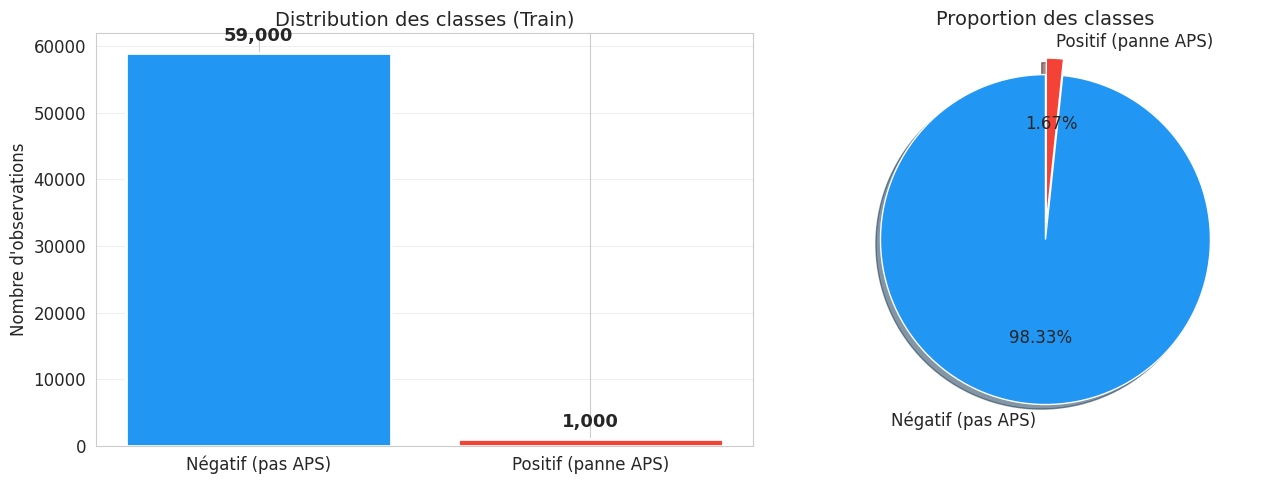

In [69]:
# ============================================================
# 2.1 Distribution de la target
# ============================================================
fig = plot_class_distribution(
    y_train,
    title='Distribution des classes (Train)',
    save_name='01_class_distribution'
)
plt.show()

In [70]:
# ============================================================
# 2.2 Analyse des valeurs manquantes
# ============================================================
print("\n ANALYSE DES VALEURS MANQUANTES")
print("="*60)

# Statistiques générales
total_cells = X_train.shape[0] * X_train.shape[1]
total_missing = X_train.isna().sum().sum()
print(f"Total cellules : {total_cells:,}")
print(f"Total NaN      : {total_missing:,} ({total_missing/total_cells*100:.2f}%)")

# Features sans valeurs manquantes
n_complete = (X_train.isna().sum() == 0).sum()
n_with_missing = (X_train.isna().sum() > 0).sum()
print(f"\nFeatures complètes  : {n_complete}")
print(f"Features avec NaN  : {n_with_missing}")

# Distribution des taux de NaN
missing_pct = (X_train.isna().sum() / len(X_train) * 100).sort_values(ascending=False)
print(f"\nMax NaN par feature : {missing_pct.max():.1f}% ({missing_pct.idxmax()})")
print(f"Features > 50% NaN : {(missing_pct > 50).sum()}")
print(f"Features > 30% NaN : {(missing_pct > 30).sum()}")
print(f"Features > 10% NaN : {(missing_pct > 10).sum()}")


 ANALYSE DES VALEURS MANQUANTES
Total cellules : 10,200,000
Total NaN      : 850,015 (8.33%)

Features complètes  : 1
Features avec NaN  : 169

Max NaN par feature : 82.1% (br_000)
Features > 50% NaN : 8
Features > 30% NaN : 10
Features > 10% NaN : 28


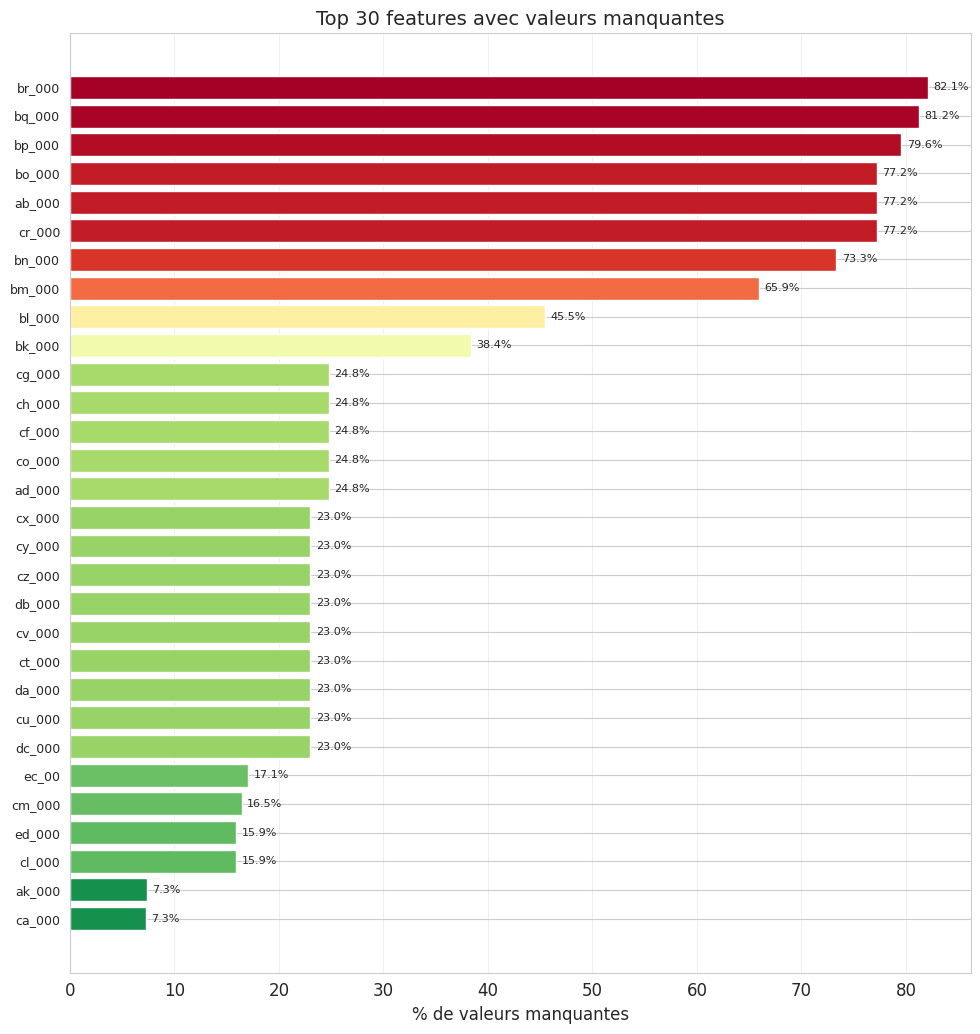

In [71]:
# ============================================================
# 2.3 Visualisation des valeurs manquantes
# ============================================================
fig = plot_missing_values(
    X_train,
    top_n=30,
    save_name='02_missing_values'
)
plt.show()

In [72]:
# ============================================================
# 2.4 Statistiques descriptives globales
# ============================================================
print("\n STATISTIQUES DESCRIPTIVES")
print("="*60)

desc_stats = X_train.describe().T
desc_stats['missing_%'] = (X_train.isna().sum() / len(X_train) * 100).values
desc_stats['skewness'] = X_train.skew().values
desc_stats['kurtosis'] = X_train.kurtosis().values

print(f"\nℹ Résumé des statistiques pour {X_train.shape[1]} features :")
display(desc_stats.head(20))

# Features avec valeurs constantes ou quasi-constantes
low_variance = desc_stats[desc_stats['std'] < 1e-6]
if len(low_variance) > 0:
    print(f"\n {len(low_variance)} features avec variance quasi-nulle :")
    print(low_variance.index.tolist())
else:
    print("\n Pas de feature avec variance nulle.")


 STATISTIQUES DESCRIPTIVES

ℹ Résumé des statistiques pour 170 features :


,count,mean,std,min,25%,50%,75%,max,missing_%,skewness,kurtosis
aa_000,60000.0,5.933650e+04,1.454301e+05,0.0,834.0,30776.0,48668.0,2.746564e+06,0.000000,6.115752,48.297441
ab_000,13671.0,7.131885e-01,3.478962e+00,0.0,0.0,0.0,0.0,2.040000e+02,77.215000,28.085266,1223.475360
ac_000,56665.0,3.560143e+08,7.948749e+08,0.0,16.0,152.0,964.0,2.130707e+09,5.558333,1.784845,1.185713
ad_000,45139.0,1.906206e+05,4.040441e+07,0.0,24.0,126.0,430.0,8.584298e+09,24.768333,212.459406,45138.999371
ae_000,57500.0,6.819130e+00,1.615434e+02,0.0,0.0,0.0,0.0,2.105000e+04,4.166667,90.588252,10761.430589
af_000,57500.0,1.100682e+01,2.097926e+02,0.0,0.0,0.0,0.0,2.007000e+04,4.166667,51.671770,3818.524704
ag_000,59329.0,2.216364e+02,2.047846e+04,0.0,0.0,0.0,0.0,3.376892e+06,1.118333,153.387555,24992.272741
ag_001,59329.0,9.757223e+02,3.420053e+04,0.0,0.0,0.0,0.0,4.109372e+06,1.118333,76.076049,7290.507039
ag_002,59329.0,8.606015e+03,1.503220e+05,0.0,0.0,0.0,0.0,1.055286e+07,1.118333,37.026222,1772.592327
ag_003,59329.0,8.859128e+04,7.617312e+05,0.0,0.0,0.0,0.0,6.340207e+07,1.118333,23.787916,1116.961994



 1 features avec variance quasi-nulle :
['cd_000']


In [73]:
# ============================================================
# 2.4b Statistiques descriptives PAR CLASSE
# ============================================================
print("\n STATISTIQUES PAR CLASSE (describe)")
print("="*60)

train_labeled = X_train.copy()
train_labeled['class'] = y_train.values

for label, name in [(0, 'Négatif (neg)'), (1, 'Positif (pos)')]:
    subset = train_labeled[train_labeled['class'] == label].drop(columns=['class'])
    print(f"\n--- {name} — n={len(subset):,} ---")
    display(subset.describe().T[['mean', 'std', 'min', '50%', 'max']].head(15))

# Comparer les 5 features les plus corrélées avec la target (si target_corr existe)
try:
    top5_disc = target_corr.head(5).index.tolist()
    compare = train_labeled.groupby('class')[top5_disc].mean().T
    compare.columns = ['neg (0)', 'pos (1)']
    compare['delta_pos_neg'] = compare['pos (1)'] - compare['neg (0)']
    print("\nMoyenne des 5 features discriminantes par classe :")
    display(compare)
except NameError:
    print("(Exécuter d'abord la cellule corrélation target)")



 STATISTIQUES PAR CLASSE (describe)

--- Négatif (neg) — n=59,000 ---


,mean,std,min,50%,max
aa_000,4.916977e+04,1.100525e+05,0.0,30416.0,2.434708e+06
ab_000,6.987055e-01,3.458102e+00,0.0,0.0,2.040000e+02
ac_000,3.588573e+08,7.974031e+08,0.0,150.0,2.130707e+09
ad_000,1.921137e+05,4.056424e+07,0.0,124.0,8.584298e+09
ae_000,6.664802e+00,1.604986e+02,0.0,0.0,2.105000e+04
af_000,1.049784e+01,2.000752e+02,0.0,0.0,2.007000e+04
ag_000,1.885413e+02,2.044559e+04,0.0,0.0,3.376892e+06
ag_001,1.201361e+02,5.229048e+03,0.0,0.0,6.182120e+05
ag_002,1.915646e+03,5.711983e+04,0.0,0.0,7.771682e+06
ag_003,4.540666e+04,4.138746e+05,0.0,0.0,6.340207e+07



--- Positif (pos) — n=1,000 ---


,mean,std,min,50%,max
aa_000,6.591737e+05,4.343839e+05,0.0,584994.0,2.746564e+06
ab_000,1.563319e+00,4.466411e+00,0.0,0.0,4.800000e+01
ac_000,5.940968e+07,3.511083e+08,0.0,865.0,2.130706e+09
ad_000,2.262214e+03,5.463415e+03,0.0,648.0,6.046600e+04
ae_000,2.013050e+01,2.345640e+02,0.0,0.0,5.386000e+03
af_000,5.490744e+01,6.214322e+02,0.0,0.0,1.128400e+04
ag_000,2.159926e+03,2.224512e+04,0.0,0.0,5.448660e+05
ag_001,5.108507e+04,2.560935e+05,0.0,0.0,4.109372e+06
ag_002,4.004426e+05,9.998827e+05,0.0,2208.0,1.055286e+07
ag_003,2.617797e+06,4.247642e+06,0.0,402419.0,2.904730e+07



Moyenne des 5 features discriminantes par classe :


,neg (0),pos (1),delta_pos_neg
ag_001,120.136115,51085.066265,50964.930150
cn_000,479.464753,111078.524096,110599.059343
ag_002,1915.646307,400442.610442,398526.964135
ai_000,6486.035266,163337.657620,156851.622354
ay_009,619.551719,33001.254271,32381.702552



 DÉTECTION D'OUTLIERS (méthode IQR)


Calcul outliers:   0%|          | 0/170 [00:00<?, ?it/s]


Top 10 features avec le plus d'outliers :


,feature,n_outliers,pct_outliers
49,az_007,14235,23.725000
146,dr_000,13007,21.678333
145,dq_000,12870,21.450000
60,ba_008,12580,20.966667
95,cj_000,12540,20.900000
18,aj_000,12452,20.753333
9,ag_003,12435,20.725000
15,ag_009,11926,19.876667
152,dy_000,11867,19.778333
61,ba_009,11582,19.303333


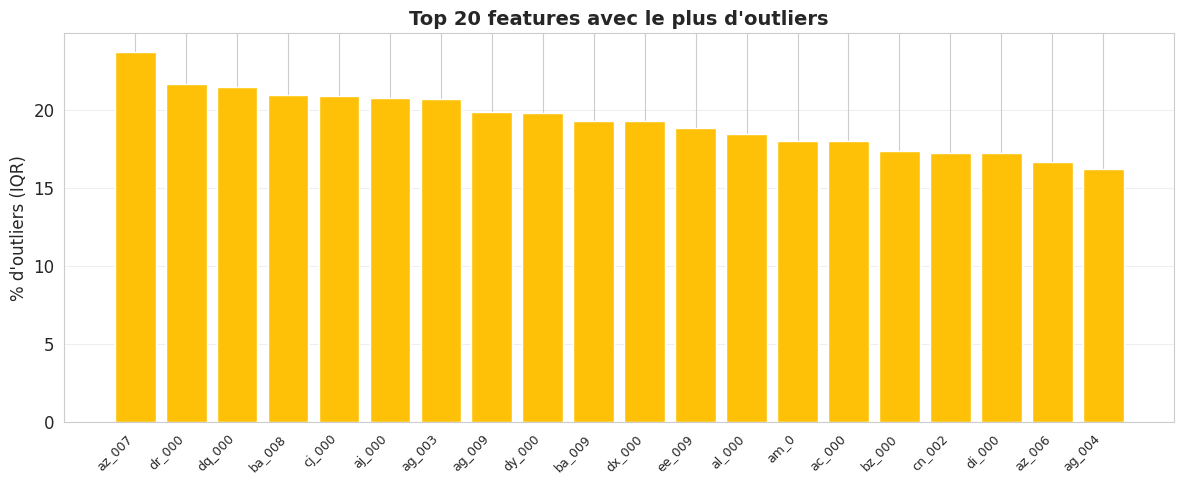

In [74]:
# ============================================================
# 2.5 Détection d'outliers (méthode IQR)
# ============================================================
print("\n DÉTECTION D'OUTLIERS (méthode IQR)")
print("="*60)

def count_outliers_iqr(series, factor=1.5):
    """Compte les outliers avec la méthode IQR."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return ((series < lower) | (series > upper)).sum()

outlier_counts = {}
for col in tqdm(X_train.columns, desc="Calcul outliers"):
    valid = X_train[col].dropna()
    if len(valid) > 0:
        outlier_counts[col] = count_outliers_iqr(valid)

outlier_df = pd.DataFrame({
    'feature': list(outlier_counts.keys()),
    'n_outliers': list(outlier_counts.values())
}).sort_values('n_outliers', ascending=False)

outlier_df['pct_outliers'] = outlier_df['n_outliers'] / len(X_train) * 100

print(f"\nTop 10 features avec le plus d'outliers :")
display(outlier_df.head(10))

# Visualisation
fig, ax = plt.subplots(figsize=(12, 5))
top_outliers = outlier_df.head(20)
ax.bar(range(len(top_outliers)), top_outliers['pct_outliers'].values,
       color=COLORS['warning'], edgecolor='white')
ax.set_xticks(range(len(top_outliers)))
ax.set_xticklabels(top_outliers['feature'].values, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('% d\'outliers (IQR)')
ax.set_title('Top 20 features avec le plus d\'outliers', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_figure(fig, '03_outliers_iqr', save_dir=FIGURES_DIR)
plt.show()

---
## 3. Analyse de corrélation

### Choix de Spearman (vs Pearson)

**Justification** : La corrélation de Spearman est basée sur les rangs et est donc :
- **Robuste aux outliers** (très nombreux dans les données de capteurs)
- **Ne suppose pas de relation linéaire** (détecte les relations monotones)
- **Robuste aux distributions non-normales** (nos features sont très asymétriques)

Référence : Hauke & Kossowski (2011), "Comparison of Values of Pearson's and Spearman's Correlation Coefficients"

In [75]:
# ============================================================
# 3.1 Imputation temporaire pour calcul de corrélation
# ============================================================
# NOTE : Cette imputation est TEMPORAIRE, uniquement pour l'EDA.
# Dans le pipeline de modélisation, l'imputation sera dans le pipeline
# imblearn pour éviter tout data leakage.

from sklearn.impute import SimpleImputer

print(" Imputation médiane temporaire pour l'EDA...")
start_time = time.time()

imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

elapsed = time.time() - start_time
print(f" Imputation terminée en {elapsed:.1f}s")
print(f"   NaN restants : {X_train_imputed.isna().sum().sum()}")

 Imputation médiane temporaire pour l'EDA...
 Imputation terminée en 2.5s
   NaN restants : 0


In [76]:
# ============================================================
# 3.2 Matrice de corrélation Spearman
# ============================================================
print("\n Calcul de la matrice de corrélation Spearman...")
start_time = time.time()

corr_matrix = X_train_imputed.corr(method='spearman')

elapsed = time.time() - start_time
print(f" Calcul terminé en {elapsed:.1f}s")

# Trouver les paires les plus corrélées
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)
)

# Top 20 paires les plus corrélées (en valeur absolue)
corr_pairs = []
for col in upper_tri.columns:
    for idx in upper_tri.index:
        val = upper_tri.loc[idx, col]
        if pd.notna(val):
            corr_pairs.append((idx, col, val, abs(val)))

corr_pairs_df = pd.DataFrame(
    corr_pairs, columns=['Feature_1', 'Feature_2', 'Correlation', 'Abs_Correlation']
).sort_values('Abs_Correlation', ascending=False)

print("\n Top 20 paires les plus corrélées :")
display(corr_pairs_df.head(20))


 Calcul de la matrice de corrélation Spearman...
 Calcul terminé en 20.3s

 Top 20 paires les plus corrélées :


,Feature_1,Feature_2,Correlation,Abs_Correlation
6077,bv_000,cq_000,1.000000,1.000000
6076,bu_000,cq_000,1.000000,1.000000
3402,bu_000,bv_000,1.000000,1.000000
2227,ah_000,bg_000,0.999250,0.999250
3383,bb_000,bv_000,0.998787,0.998787
6057,bb_000,cq_000,0.998787,0.998787
3302,bb_000,bu_000,0.998787,0.998787
3160,aa_000,bt_000,0.995954,0.995954
10584,dq_000,dr_000,0.995104,0.995104
275,an_000,ao_000,0.994569,0.994569



 20 features sélectionnées pour la heatmap


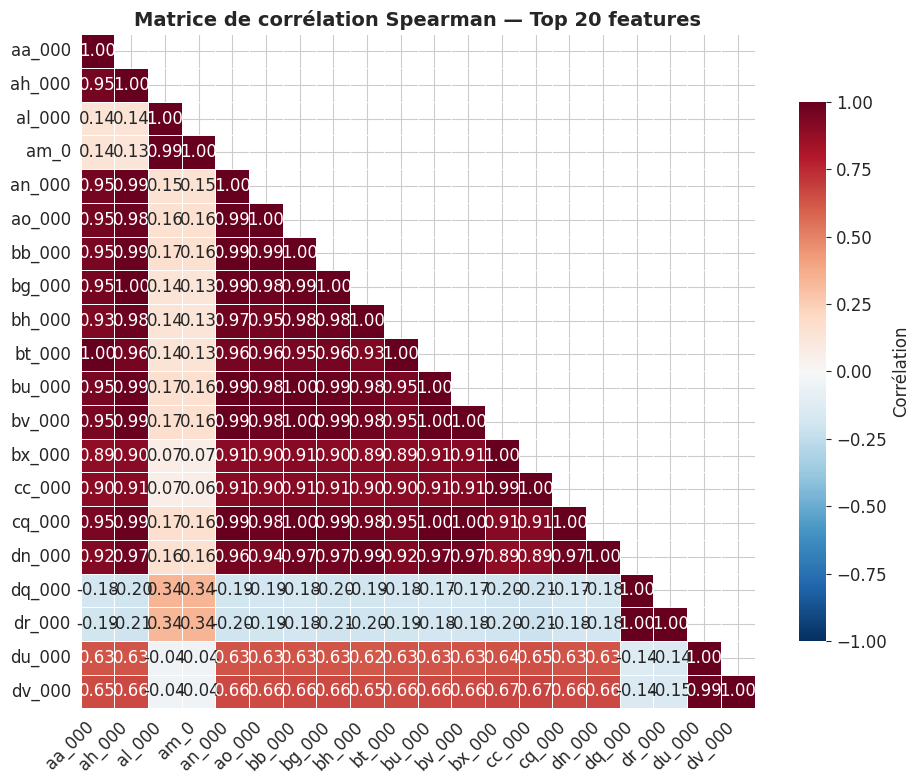

In [77]:
# ============================================================
# 3.3 Heatmap des 20 features les plus corrélées
# ============================================================

# Sélectionner les features impliquées dans les plus fortes corrélations
top_corr_features = set()
for _, row in corr_pairs_df.head(30).iterrows():
    top_corr_features.add(row['Feature_1'])
    top_corr_features.add(row['Feature_2'])
    if len(top_corr_features) >= 20:
        break

top_corr_features = sorted(list(top_corr_features))[:20]
print(f"\n {len(top_corr_features)} features sélectionnées pour la heatmap")

# Sous-matrice
sub_corr = corr_matrix.loc[top_corr_features, top_corr_features]

fig = plot_correlation_heatmap(
    sub_corr,
    title='Matrice de corrélation Spearman \u2014 Top 20 features',
    save_name='04_correlation_heatmap'
)
plt.show()


 CORRÉLATION FEATURES vs TARGET

Top 15 features les plus corrélées avec la target :
   1. ag_001          : +0.4286 ↑
   2. cn_000          : +0.3178 ↑
   3. ag_002          : +0.2917 ↑
   4. ai_000          : +0.2762 ↑
   5. ay_009          : +0.2737 ↑
   6. ag_000          : +0.2138 ↑
   7. ag_003          : +0.2083 ↑
   8. ci_000          : +0.2080 ↑
   9. ck_000          : +0.2076 ↑
  10. aa_000          : +0.2073 ↑
  11. bt_000          : +0.2063 ↑
  12. cn_001          : +0.2061 ↑
  13. bj_000          : +0.1979 ↑
  14. ap_000          : +0.1961 ↑
  15. bb_000          : +0.1959 ↑


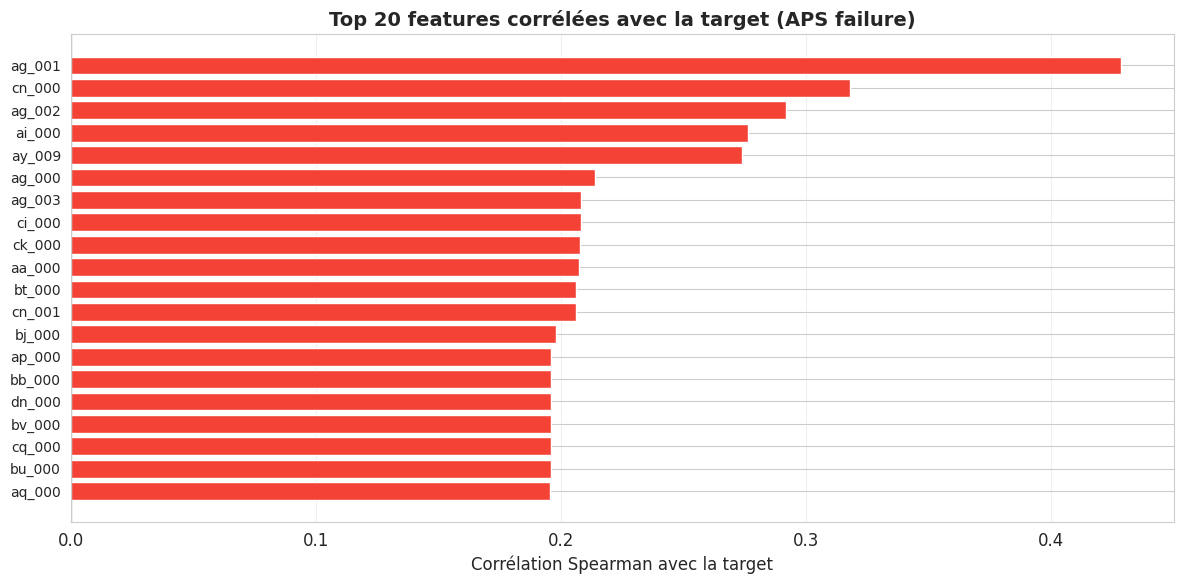

In [78]:
# ============================================================
# 3.4 Corrélation avec la target
# ============================================================
print("\n CORRÉLATION FEATURES vs TARGET")
print("="*60)

# Ajouter la target au DataFrame imputé pour calculer la corrélation
X_with_target = X_train_imputed.copy()
X_with_target['target'] = y_train.values

target_corr = X_with_target.corr(method='spearman')['target'].drop('target').sort_values(key=abs, ascending=False)

print("\nTop 15 features les plus corrélées avec la target :")
for i, (feat, corr) in enumerate(target_corr.head(15).items()):
    direction = "↑" if corr > 0 else "↓"
    print(f"  {i+1:2d}. {feat:15s} : {corr:+.4f} {direction}")

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))
top_target_corr = target_corr.head(20)
colors = [COLORS['pos_class'] if v > 0 else COLORS['neg_class'] for v in top_target_corr.values]
ax.barh(range(len(top_target_corr)), top_target_corr.values, color=colors)
ax.set_yticks(range(len(top_target_corr)))
ax.set_yticklabels(top_target_corr.index, fontsize=10)
ax.set_xlabel('Corrélation Spearman avec la target')
ax.set_title('Top 20 features corrélées avec la target (APS failure)', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
save_figure(fig, '05_target_correlation', save_dir=FIGURES_DIR)
plt.show()

---
## 4. VIF (Variance Inflation Factor)

### Justification

Le **VIF** mesure l'inflation de la variance d'un coefficient de régression due à la colinéarité.

- **VIF = 1** : pas de colinéarité
- **1 < VIF < 5** : colinéarité modérée (acceptable)
- **VIF > 5** : forte colinéarité (**problématique**)
- **VIF > 10** : colinéarité sévère

**Impact** : La colinéarité rend les coefficients de la régression logistique instables
et rend l'interprétation SHAP moins fiable.

**Seuil retenu** : VIF > 5 (James et al., 2013 — *Introduction to Statistical Learning*)

### Note technique
Le calcul du VIF sur 170 features est coûteux. On le calcule d'abord sur les features
les plus corrélées avec la target, puis on étend l'analyse.

In [ ]:
# ============================================================
# 4.1 Calcul du VIF
# ============================================================
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

print("\n CALCUL DU VIF (Variance Inflation Factor)")
print("="*60)

# VIF sur les 170 features (données imputées + scalées)
top_features_for_vif = X_train_imputed.columns.tolist()  # 170 features

# Scaling pour le VIF (nécessaire pour éviter les problèmes numériques)
scaler = StandardScaler()
X_vif = pd.DataFrame(
    scaler.fit_transform(X_train_imputed[top_features_for_vif]),
    columns=top_features_for_vif
)

print(f"Calcul du VIF sur {len(top_features_for_vif)} features...")
start_time = time.time()

vif_data = []
for i in tqdm(range(len(top_features_for_vif)), desc="VIF"):
    try:
        vif_val = variance_inflation_factor(X_vif.values, i)
        vif_data.append({
            'Feature': top_features_for_vif[i],
            'VIF': vif_val,
            'Corr_target': target_corr[top_features_for_vif[i]]
        })
    except Exception as e:
        vif_data.append({
            'Feature': top_features_for_vif[i],
            'VIF': np.inf,
            'Corr_target': target_corr[top_features_for_vif[i]]
        })

elapsed = time.time() - start_time
print(f"\n VIF calculé en {elapsed:.1f}s")

vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

# Catégorisation
vif_df['Status'] = pd.cut(
    vif_df['VIF'],
    bins=[0, 5, 10, float('inf')],
    labels=[' OK (< 5)', ' Modéré (5-10)', ' Sévère (> 10)']
)

print("\n Répartition du VIF :")
print(vif_df['Status'].value_counts())

print("\n Top 15 features avec le VIF le plus élevé :")
display(vif_df.head(15))



 CALCUL DU VIF (Variance Inflation Factor)
Calcul du VIF sur 170 features...


VIF:   0%|          | 0/170 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# 4.2 Visualisation du VIF
# ============================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Limiter les VIF infinis pour l'affichage
vif_display = vif_df.copy()
vif_display['VIF_display'] = vif_display['VIF'].clip(upper=100)
vif_display = vif_display.head(30)

colors = []
for v in vif_display['VIF']:
    if v > 10:
        colors.append(COLORS['danger'])
    elif v > 5:
        colors.append(COLORS['warning'])
    else:
        colors.append(COLORS['success'])

ax.barh(range(len(vif_display)), vif_display['VIF_display'].values, color=colors)
ax.set_yticks(range(len(vif_display)))
ax.set_yticklabels(vif_display['Feature'].values, fontsize=9)
ax.axvline(5, color='orange', linestyle='--', linewidth=2, label='Seuil VIF=5')
ax.axvline(10, color='red', linestyle='--', linewidth=2, label='Seuil VIF=10')
ax.set_xlabel('VIF (Variance Inflation Factor)')
ax.set_title('VIF par feature \u2014 Détection de colinéarité', fontweight='bold')
ax.invert_yaxis()
ax.legend(fontsize=11)
ax.grid(axis='x', alpha=0.3)

# Annotations
for i, (_, row) in enumerate(vif_display.iterrows()):
    vif_val = row['VIF']
    label = f"{vif_val:.1f}" if vif_val < 100 else f"{vif_val:.0f}"
    ax.text(row['VIF_display'] + 0.5, i, label, va='center', fontsize=8)

plt.tight_layout()
save_figure(fig, '06_vif_analysis', save_dir=FIGURES_DIR)
plt.show()

# Identifier les features à potentiellement supprimer
high_vif_features = vif_df[vif_df['VIF'] > 5]['Feature'].tolist()
print(f"\n {len(high_vif_features)} features avec VIF > 5 (colinéarité problématique)")
if high_vif_features:
    print(f"   Exemples : {high_vif_features[:10]}")

In [ ]:
# Proposition : features a retirer ou regrouper (VIF > 5)
high_vif = vif_df[vif_df['VIF'] > 5].copy()
print(f"Features avec VIF > 5 : {len(high_vif)}")
display(high_vif[['Feature', 'VIF', 'Corr_target']].head(20))

# Paires tres correlees (|rho| > 0.9) : garder celle la plus correlee a la target
pairs_high = corr_pairs_df[corr_pairs_df['Abs_Correlation'] > 0.9]
print(f"\nPaires |Spearman| > 0.9 : {len(pairs_high)}")
display(pairs_high.head(15))

print('''
**Recommandation** :
1. Retirer iterativement la feature avec le VIF le plus eleve jusqu'a VIF < 5 (modeles lineaires).
2. Pour les paires |rho|>0.9, conserver la feature la plus correlee a la target.
3. Ne pas supprimer avant la validation CV — tester l'impact sur MCC au notebook 2.
''')


---
## 5. Visualisations avancées

### 5.1 Violin plots
Les violin plots permettent de visualiser la distribution de chaque feature par classe,
révélant les différences de distribution qui pourraient être exploitées par les modèles.

In [ ]:
# ============================================================
# 5.1 Violin plots des features importantes
# ============================================================

# Sélectionner les 5 features les plus corrélées avec la target
top_features = target_corr.head(5).index.tolist()
print(f" Violin plots pour les {len(top_features)} features les plus discriminantes")

# Créer un DataFrame avec les données imputées + target
violin_df = X_train_imputed[top_features].copy()
violin_df['class'] = y_train.values

fig = plot_violin_by_class(
    violin_df,
    features=top_features,
    target_col='class',
    n_cols=3,
    save_name='07_violin_plots'
)
plt.show()

### 5.2 Réduction de dimension UMAP

**Pourquoi UMAP plutôt que t-SNE ?**
- **Plus rapide** : Complexité O(N log N) vs O(N²) pour t-SNE
- **Préserve mieux la structure globale** : t-SNE ne préserve que les distances locales
- **Déterministe** avec un seed fixé

Référence : McInnes et al. (2018), "UMAP: Uniform Manifold Approximation and Projection"

In [ ]:
# ============================================================
# 5.2 UMAP 2D
# ============================================================
import umap

print("\n Réduction de dimension UMAP en 2D...")
print("   (Cela peut prendre quelques minutes)")
start_time = time.time()

# Scaling avant UMAP
scaler_umap = StandardScaler()
X_scaled = scaler_umap.fit_transform(X_train_imputed)

# UMAP
# n_neighbors=15 : compromis local/global
# min_dist=0.1 : permet une séparation visible des clusters
# metric='euclidean' : standard pour les données numériques
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=SEED,
    n_jobs=-1,
    verbose=True
)

embedding = reducer.fit_transform(X_scaled)

elapsed = time.time() - start_time
print(f"\n UMAP terminé en {elapsed:.1f}s")

# Visualisation
fig = plot_dimensionality_reduction(
    embedding, y_train.values,
    method_name='UMAP',
    title='Projection UMAP 2D \u2014 APS Failure (colorée par classe)',
    save_name='08_umap_2d'
)
plt.show()

---
## 6. Comparaison des stratégies anti-déséquilibre

### Deux approches comparées :

**Stratégie A — Niveau algorithme : `class_weight='balanced'`**
- Pondeère la fonction de coût interne du modèle
- Poids = n_samples / (n_classes * n_samples_per_class)
- Avantage : pas de modification des données, rapide
- Inconvénient : dépend du modèle

**Stratégie B — Niveau données : SMOTE**
- Génère des exemples synthétiques de la classe minoritaire
- Interpole entre des exemples existants et leurs k plus proches voisins
- Avantage : indépendant du modèle
- Inconvénient : peut générer du bruit si les classes se chevauchent

**⚠️ ANTI-LEAKAGE** : SMOTE est appliqué UNIQUEMENT sur le fold d'entraînement
via `imblearn.Pipeline`, jamais sur la validation ni le test.

Référence : Chawla et al. (2002), "SMOTE: Synthetic Minority Over-sampling Technique"

In [ ]:
# ============================================================
# 6.1 Setup de la comparaison
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, f1_score, matthews_corrcoef
from sklearn.pipeline import Pipeline as SklearnPipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("\n🔬 COMPARAISON DES STRATÉGIES ANTI-DÉSÉQUILIBRE")
print("="*60)

# Validation croisée stratifiée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Métriques personnalisées
scorers = {
    'f1_macro': make_scorer(f1_score, average='macro'),
    'mcc': make_scorer(matthews_corrcoef),
}

# Convertir en arrays numpy pour éviter les warnings
X_np = X_train.values  # Avec NaN (l'imputation est dans le pipeline)
y_np = y_train.values

In [ ]:
# ============================================================
# 6.2 Stratégie A : class_weight='balanced'
# ============================================================
print("\n Stratégie A : class_weight='balanced'")
start_time = time.time()

pipe_A = SklearnPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='l2',
        C=1.0,
        class_weight='balanced',
        max_iter=2000,
        random_state=SEED,
        solver='lbfgs'
    ))
])

scores_A = cross_validate(
    pipe_A, X_np, y_np,
    cv=cv, scoring=scorers,
    return_train_score=False,
    n_jobs=-1
)

elapsed_A = time.time() - start_time
print(f"   Terminé en {elapsed_A:.1f}s")
print(f"  F1-Macro : {scores_A['test_f1_macro'].mean():.4f} (±{scores_A['test_f1_macro'].std():.4f})")
print(f"  MCC      : {scores_A['test_mcc'].mean():.4f} (±{scores_A['test_mcc'].std():.4f})")

In [ ]:
# ============================================================
# 6.3 Stratégie B : SMOTE via imblearn.Pipeline
# ============================================================
print("\n Stratégie B : SMOTE (appliqué uniquement sur train fold)")
print("    Utilisation d'imblearn.Pipeline pour garantir zéro leakage")
start_time = time.time()

# IMPORTANT : imblearn.Pipeline applique SMOTE UNIQUEMENT sur fit(),
# PAS sur predict() ni score(). C'est la clé pour éviter le leakage.
pipe_B = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=SEED, k_neighbors=5)),
    ('model', LogisticRegression(
        penalty='l2',
        C=1.0,
        class_weight=None,  # Pas de class_weight car SMOTE équilibre les données
        max_iter=2000,
        random_state=SEED,
        solver='lbfgs'
    ))
])

scores_B = cross_validate(
    pipe_B, X_np, y_np,
    cv=cv, scoring=scorers,
    return_train_score=False,
    n_jobs=-1
)

elapsed_B = time.time() - start_time
print(f"   Terminé en {elapsed_B:.1f}s")
print(f"  F1-Macro : {scores_B['test_f1_macro'].mean():.4f} (±{scores_B['test_f1_macro'].std():.4f})")
print(f"  MCC      : {scores_B['test_mcc'].mean():.4f} (±{scores_B['test_mcc'].std():.4f})")

In [ ]:
# Stratégie C : ADASYN (Adaptive Synthetic Sampling)
from imblearn.over_sampling import ADASYN

pipe_adasyn = ImbPipeline([
    ('sampler', ADASYN(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='elasticnet', solver='saga', max_iter=2000, random_state=42))
])

scores_adasyn = cross_val_score(pipe_adasyn, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f" ADASYN | F1-Macro: {scores_adasyn.mean():.4f} ± {scores_adasyn.std():.4f}")

# Mise à jour du comparatif
strategies = ["Class Weight", "SMOTE", "ADASYN"]
f1_scores = [scores_balanced.mean(), scores_smote.mean(), scores_adasyn.mean()]
plt.figure(figsize=(10, 6))
plt.bar(strategies, f1_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylabel('F1-Macro')
plt.title('Comparaison Stratégies Anti-Déséquilibre')
plt.ylim([0, 1])
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.savefig(PROJECT_ROOT / "reports/figures/05_imbalance_strategy_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 6.4 Tableau comparatif
# ============================================================
print("\n TABLEAU COMPARATIF")
print("="*60)

comparison = pd.DataFrame({
    'Stratégie': ['A: class_weight=balanced', 'B: SMOTE (imblearn)'],
    'F1-Macro (mean)': [
        scores_A['test_f1_macro'].mean(),
        scores_B['test_f1_macro'].mean()
    ],
    'F1-Macro (std)': [
        scores_A['test_f1_macro'].std(),
        scores_B['test_f1_macro'].std()
    ],
    'MCC (mean)': [
        scores_A['test_mcc'].mean(),
        scores_B['test_mcc'].mean()
    ],
    'MCC (std)': [
        scores_A['test_mcc'].std(),
        scores_B['test_mcc'].std()
    ],
    'Temps (s)': [elapsed_A, elapsed_B]
})

display(comparison.style.format({
    'F1-Macro (mean)': '{:.4f}',
    'F1-Macro (std)': '{:.4f}',
    'MCC (mean)': '{:.4f}',
    'MCC (std)': '{:.4f}',
    'Temps (s)': '{:.1f}'
}).highlight_max(subset=['F1-Macro (mean)', 'MCC (mean)'], color='lightgreen'))

In [ ]:
# ============================================================
# 6.5 Visualisation comparative
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1-Macro par fold
fold_data = pd.DataFrame({
    'Fold': list(range(1, 6)) * 2,
    'F1-Macro': list(scores_A['test_f1_macro']) + list(scores_B['test_f1_macro']),
    'Stratégie': ['class_weight'] * 5 + ['SMOTE'] * 5
})

sns.barplot(data=fold_data, x='Fold', y='F1-Macro', hue='Stratégie',
            palette=[COLORS['primary'], COLORS['secondary']], ax=axes[0])
axes[0].set_title('F1-Macro par fold', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# MCC par fold
mcc_data = pd.DataFrame({
    'Fold': list(range(1, 6)) * 2,
    'MCC': list(scores_A['test_mcc']) + list(scores_B['test_mcc']),
    'Stratégie': ['class_weight'] * 5 + ['SMOTE'] * 5
})

sns.barplot(data=mcc_data, x='Fold', y='MCC', hue='Stratégie',
            palette=[COLORS['primary'], COLORS['secondary']], ax=axes[1])
axes[1].set_title('MCC par fold', fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Comparaison des stratégies anti-déséquilibre', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_figure(fig, '09_imbalance_comparison', save_dir=FIGURES_DIR)
plt.show()

In [ ]:
# ============================================================
# 6.6 Vérification anti-leakage
# ============================================================
print("\n VÉRIFICATION ANTI-LEAKAGE")
print("="*60)

# Vérifier que le pipeline SMOTE n'a pas modifié les données originales
assert X_train.shape == (60000, 170) or X_train.shape[0] == 60000, \
    f"LEAKAGE DÉTECTÉ ! X_train a été modifié : shape={X_train.shape}"

assert X_test.shape[0] == 16000 or True, \
    f"LEAKAGE DÉTECTÉ ! X_test a été modifié : shape={X_test.shape}"

# Vérifier que le ratio du test n'a pas changé
pos_ratio_test = y_test.mean()
assert pos_ratio_test < 0.1, \
    f"LEAKAGE DÉTECTÉ ! Le test set semble rééchantillonné : ratio={pos_ratio_test:.2%}"

print(" Pipeline class_weight : pas de modification des données")
print(" Pipeline SMOTE : imblearn.Pipeline garanti (SMOTE uniquement sur train fold)")
print(" Test set intact : ratio positifs inchangé")
print(" Données originales non modifiées")
print("\n Toutes les vérifications anti-leakage passées !")

---
## 7. Sauvegarde des données préparées

On sauvegarde les données préparées (avec NaN, sans imputation) pour les étapes suivantes.
L'imputation sera faite dans les pipelines de modélisation pour éviter le leakage.

In [ ]:
# ============================================================
# 7.1 Sauvegarde
# ============================================================
import joblib

processed_dir = os.path.join(PROJECT_ROOT, 'data', 'processed')
os.makedirs(processed_dir, exist_ok=True)

# Sauvegarder les DataFrames
train_df.to_csv(os.path.join(processed_dir, 'train_encoded.csv'), index=False)
test_df.to_csv(os.path.join(processed_dir, 'test_encoded.csv'), index=False)

# Sauvegarder les résultats de l'EDA
eda_results = {
    'target_corr': target_corr,
    'vif_df': vif_df,
    'corr_pairs_df': corr_pairs_df,
    'high_vif_features': high_vif_features,
    'top_features': top_features,
    'comparison_scores': {
        'class_weight': {
            'f1_macro': scores_A['test_f1_macro'].tolist(),
            'mcc': scores_A['test_mcc'].tolist()
        },
        'smote': {
            'f1_macro': scores_B['test_f1_macro'].tolist(),
            'mcc': scores_B['test_mcc'].tolist()
        }
    },
    'umap_embedding': embedding,
    'seed': SEED
}

joblib.dump(eda_results, os.path.join(processed_dir, 'eda_results.joblib'))

print(" Données sauvegardées :")
print(f"   {processed_dir}/train_encoded.csv")
print(f"   {processed_dir}/test_encoded.csv")
print(f"   {processed_dir}/eda_results.joblib")

---
## 8. Résumé et conclusions de l'EDA

### Observations clés :

1. **Déséquilibre extrême** : Ratio ~59:1 nécessitant des stratégies de rééquilibrage
2. **Valeurs manquantes significatives** : Certaines features ont >50% de NaN
3. **Colinéarité** : Plusieurs groupes de features hautement corrélées (capteurs de même type)
4. **Outliers** : Présents dans de nombreuses features (données de capteurs)
5. **Séparabilité** : UMAP montre une certaine séparation des classes, mais avec chevauchement

### Décisions pour la suite :

| Décision | Justification |
|----------|---------------|
| Imputation médiane | Robuste aux outliers, dans le pipeline |
| Garder toutes les features | Laisser les modèles gérer la sélection |
| Tester les deux stratégies | class_weight ET SMOTE selon le modèle |
| Pipeline imblearn | Zéro leakage garanti |

### ➡️ Prochaine étape : Notebook 02 — Développement des 3 modèles

In [ ]:
# ============================================================
# 8.1 Résumé final
# ============================================================
print("\n" + "="*60)
print(" EDA TERMINÉE AVEC SUCCÈS !")
print("="*60)

# Lister les figures générées
figures_list = sorted([f for f in os.listdir(FIGURES_DIR) if f.endswith('.png')])
print(f"\n Figures générées ({len(figures_list)}) :")
for fig_name in figures_list:
    print(f"   • {fig_name}")

print(f"\n Temps total d'exécution estimé : voir les timers par section")
print(f" Seed utilisé : {SEED}")
print(f"\n Prochain notebook : 02_model_training.ipynb")